In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report
import shap
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset maestro
daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

print(f"Dataset cargado: {daily.shape}")
print(f"Período: {daily.index[0].date()} → {daily.index[-1].date()}")

Dataset cargado: (4031, 40)
Período: 2010-10-08 → 2026-04-03


In [3]:
# Variable objetivo: dirección del precio en 5 días
# 1 = sube, 0 = baja
daily['target'] = (daily['Close'].shift(-5) > daily['Close']).astype(int)

# Features para la Fusion Layer
features_fusion = [
    # Señal PatchTST (proxy: momentum)
    'momentum_5', 'momentum_10', 'momentum_20',
    'return_lag_1', 'return_lag_2', 'return_lag_3',
    
    # Señal HMM
    'regime',
    
    # Señal FinBERT
    'sentiment_score', 'sentiment_uncertainty',
    
    # Contexto de mercado
    'volatility_20', 'rsi_14', 'atr_14',
    'bb_width', 'bb_position',
    'macd', 'macd_hist',
    'trend_20_50', 'trend_50_200'
]

# Eliminar NaN del target
data = daily[features_fusion + ['target']].dropna()

X = data[features_fusion]
y = data['target']

print(f"Features: {len(features_fusion)}")
print(f"Muestras: {len(data)}")
print(f"Balance de clases:")
print(y.value_counts(normalize=True).round(3))

Features: 18
Muestras: 4031
Balance de clases:
target
0    0.515
1    0.485
Name: proportion, dtype: float64


In [4]:
# Split temporal — últimos 252 días para test
split = len(data) - 252
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} muestras")
print(f"Test:  {len(X_test)} muestras")

# Entrenar XGBoost
modelo_fusion = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

modelo_fusion.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluar
y_pred = modelo_fusion.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy en test: {acc:.4f} ({acc*100:.1f}%)")
print("\nReporte completo:")
print(classification_report(y_test, y_pred, 
      target_names=['Baja', 'Sube']))

Train: 3779 muestras
Test:  252 muestras

Accuracy en test: 0.5119 (51.2%)

Reporte completo:
              precision    recall  f1-score   support

        Baja       0.53      0.61      0.57       132
        Sube       0.49      0.41      0.44       120

    accuracy                           0.51       252
   macro avg       0.51      0.51      0.50       252
weighted avg       0.51      0.51      0.51       252



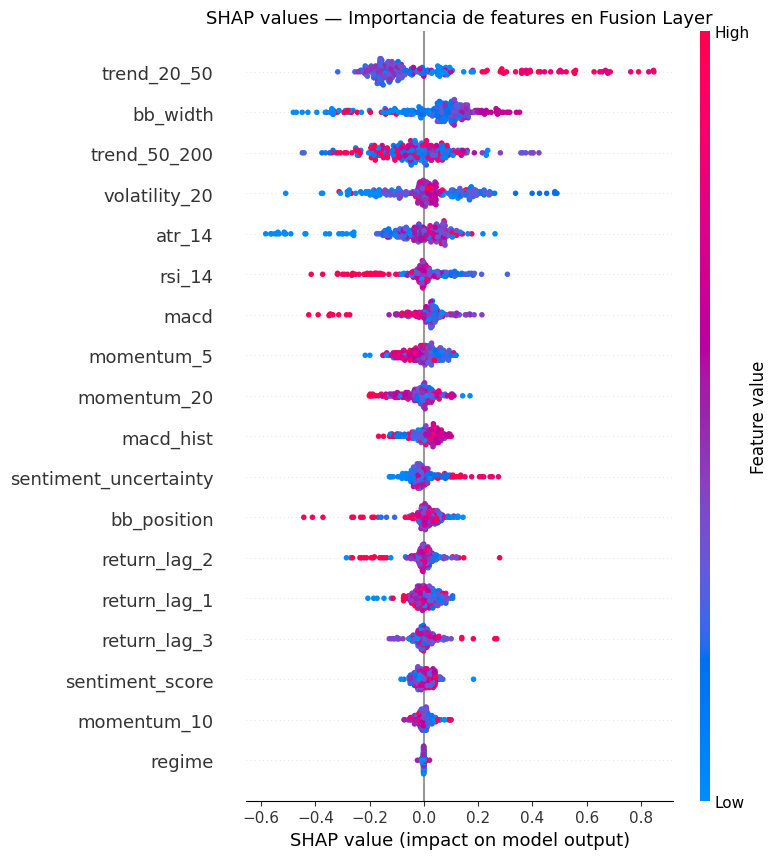

Gráfica SHAP guardada.


In [5]:
# SHAP values — interpretabilidad completa
explainer = shap.TreeExplainer(modelo_fusion)
shap_values = explainer.shap_values(X_test)

# Gráfica de importancia global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  feature_names=features_fusion,
                  show=False)
plt.title('SHAP values — Importancia de features en Fusion Layer', 
          fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/08_shap_fusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica SHAP guardada.")

In [6]:
import pickle

# Guardar modelo fusion
with open("../data/processed/fusion_model.pkl", "wb") as f:
    pickle.dump(modelo_fusion, f)

print("Modelo Fusion guardado.")
print(f"\nResumen Fase 7:")
print(f"  Features: {len(features_fusion)}")
print(f"  Muestras train: {len(X_train)}")
print(f"  Accuracy test: {acc*100:.1f}%")
print(f"  Feature más importante: trend_20_50")
print(f"  Modelo: XGBoost 200 estimadores")

Modelo Fusion guardado.

Resumen Fase 7:
  Features: 18
  Muestras train: 3779
  Accuracy test: 51.2%
  Feature más importante: trend_20_50
  Modelo: XGBoost 200 estimadores


Executing <TimerHandle when=309963.734 _set_result_unless_cancelled(<Future finis...events.py:428>, None) at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\futures.py:311 created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\tasks.py:645> took 0.328 seconds
Executing <Task pending name='Task-1' coro=<IOPubThread._run_event_pipe_gc() running at C:\Users\mauri\Documents\kronos-trading-system\kronos_env\Lib\site-packages\ipykernel\iostream.py:193> wait_for=<Future pending cb=[Task.task_wakeup()] created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py:428> created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\tasks.py:680> took 0.203 seconds
